# Frozen Transfer Learning: ResNet-50 vs Xception

This notebook presents the validation-only comparison of two frozen ImageNet backbones under one locked protocol. It reads the saved experiment results; it does not rerun training or evaluate the test set.


In [28]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'config.py').is_file() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
import config

RESULTS = PROJECT_ROOT / 'results'
CLASS_NAMES = list(config.CLASS_NAMES)


## 1. Data split and preprocessing protocol

The comparison uses `data/split_aspect.csv` for training and validation only. Both backbones use 224x224 square crops, aspect-balanced sampling, the same classifier head and optimizer, and checkpoint selection by validation macro F1. The existing test split was not loaded for these runs.


In [29]:
def split_counts(path):
    frame = pd.read_csv(path)
    frame = frame.loc[frame['status'].eq('ok')]
    return frame.pivot_table(index='split', columns='label', values='class_index', aggfunc='size', fill_value=0)

display(split_counts(config.SPLIT_CSV_PATH).rename_axis('Original split'))
display(split_counts(config.DATA_DIR / 'split_aspect.csv').rename_axis('Aspect-aware split'))


label,fire,nofire,smoke,smokefire
Original split,,,,
test,200,200,200,200
train,800,800,800,800
val,200,200,200,200


label,fire,nofire,smoke,smokefire
Aspect-aware split,,,,
test,200,200,200,200
train,800,800,800,800
val,200,200,200,200


## 2. Training implementation (optional)

The shared implementation is [`src/training/xception_aspect_frozen.py`](../src/training/xception_aspect_frozen.py). It accepts `--architecture xception` or `--architecture resnet50`; the same manifest, crop, sampler, classifier head, optimizer, and checkpoint rule are used for both.

Example command for one run (repeat with each backbone and seed 42, 7, 123, and 2024):

```powershell
python -m src.training.xception_aspect_frozen --architecture resnet50 --split-csv data/split_aspect.csv --crop-mode square --aspect-balance --image-size 224 --seed 42 --run-name resnet50_square_aspect_balanced_224_seed_42
```

The saved comparison artifacts below are used by default. Enable the cell only when intentionally rerunning the experiment; training requires the image dataset configured locally.


## 3. Per-seed validation metrics

Scores are displayed as percentages. The source CSV stores values as fractions between 0 and 1.


In [30]:
comparison = pd.read_csv(RESULTS / 'frozen_backbone_comparison_per_seed.csv')
comparison['backbone'] = comparison['architecture'].map({'xception': 'Xception', 'resnet50': 'ResNet-50'})
comparison['seed'] = comparison['seed'].astype(int)
comparison = comparison.sort_values(['backbone', 'seed'])
expected_seeds = {42, 7, 123, 2024}
assert set(comparison['backbone']) == {'Xception', 'ResNet-50'}
assert all(set(group['seed']) == expected_seeds for _, group in comparison.groupby('backbone'))
metric_columns = ['accuracy', 'macro_f1'] + [f'f1_{name}' for name in CLASS_NAMES]
per_seed = comparison[['backbone', 'seed', *metric_columns]].copy()
per_seed[metric_columns] *= 100
display(per_seed.style.format({name: '{:.2f}%' for name in metric_columns}))


,backbone,seed,accuracy,macro_f1,f1_fire,f1_nofire,f1_smoke,f1_smokefire
5,ResNet-50,7,93.25%,93.23%,87.86%,98.23%,98.04%,88.78%
4,ResNet-50,42,93.62%,93.62%,89.95%,97.98%,98.27%,88.28%
6,ResNet-50,123,93.75%,93.74%,89.97%,98.49%,98.27%,88.24%
7,ResNet-50,2024,92.75%,92.76%,88.55%,98.01%,97.23%,87.25%
1,Xception,7,88.62%,88.64%,85.86%,94.63%,91.97%,82.09%
0,Xception,42,90.25%,90.26%,88.32%,94.82%,93.30%,84.58%
2,Xception,123,89.38%,89.34%,88.22%,94.21%,92.42%,82.53%
3,Xception,2024,87.50%,87.59%,85.64%,92.39%,91.30%,81.04%


## 4. Mean and population variance

Variance is calculated across the four seeds with `ddof=0`. Mean scores are shown as percentages; variance remains on the original 0-to-1 score scale.


In [31]:
summary = comparison.groupby('backbone')[metric_columns].agg(['mean', lambda values: np.var(values, ddof=0)])
summary.columns = [f'{metric}_{stat}'.replace('<lambda_0>', 'variance') for metric, stat in summary.columns]
summary_table = pd.DataFrame(index=summary.index)
for metric in metric_columns:
    summary_table[f'{metric} (mean +/- variance)'] = [
        f"{summary.loc[backbone, metric + '_mean'] * 100:.2f}% +/- {summary.loc[backbone, metric + '_variance']:.6f}"
        for backbone in summary.index
    ]
summary_table.index.name = 'Backbone'
display(summary_table)


,accuracy (mean +/- variance),macro_f1 (mean +/- variance),f1_fire (mean +/- variance),f1_nofire (mean +/- variance),f1_smoke (mean +/- variance),f1_smokefire (mean +/- variance)
Backbone,,,,,,
ResNet-50,93.34% +/- 0.000015,93.34% +/- 0.000015,89.08% +/- 0.000083,98.18% +/- 0.000004,97.95% +/- 0.000018,88.14% +/- 0.000031
Xception,88.94% +/- 0.000102,88.96% +/- 0.000095,87.01% +/- 0.000160,94.01% +/- 0.000093,92.25% +/- 0.000053,82.56% +/- 0.000165


In [33]:
means = comparison.groupby('backbone')[metric_columns].mean()
variances = comparison.groupby('backbone')[metric_columns].agg(
    lambda values: np.var(values, ddof=0)
)
summary_table = pd.DataFrame(index=means.index)
for metric in metric_columns:
    summary_table[f'{metric} (mean +/- variance)'] = [
        f"{means.loc[backbone, metric] * 100:.2f}% +/- {variances.loc[backbone, metric]:.6f}"
        for backbone in means.index
    ]
summary_table.index.name = 'Backbone'
display(summary_table)


,accuracy (mean +/- variance),macro_f1 (mean +/- variance),f1_fire (mean +/- variance),f1_nofire (mean +/- variance),f1_smoke (mean +/- variance),f1_smokefire (mean +/- variance)
Backbone,,,,,,
ResNet-50,93.34% +/- 0.000015,93.34% +/- 0.000015,89.08% +/- 0.000083,98.18% +/- 0.000004,97.95% +/- 0.000018,88.14% +/- 0.000031
Xception,88.94% +/- 0.000102,88.96% +/- 0.000095,87.01% +/- 0.000160,94.01% +/- 0.000093,92.25% +/- 0.000053,82.56% +/- 0.000165


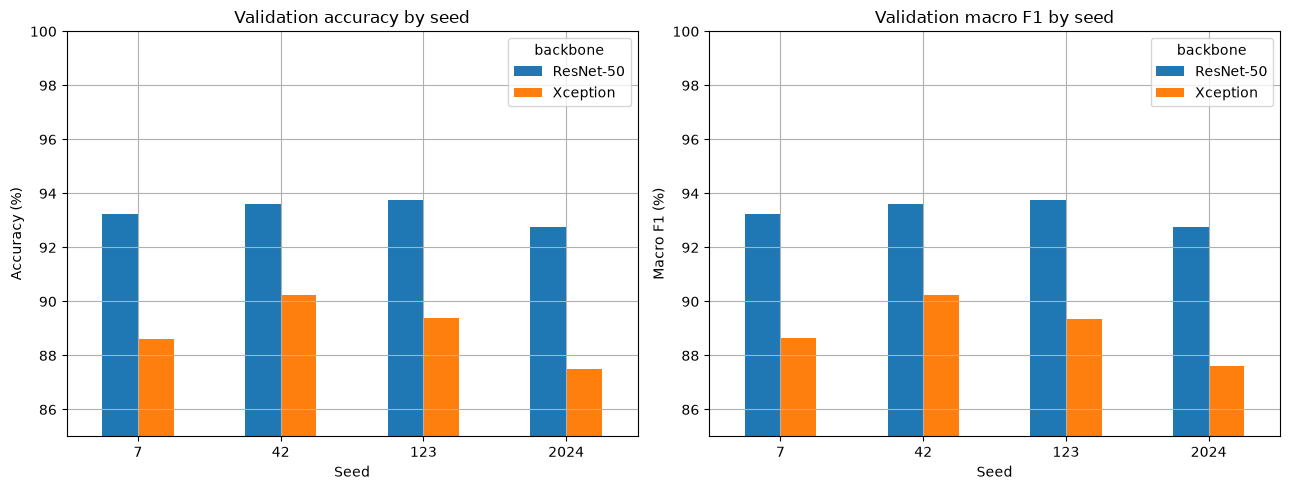

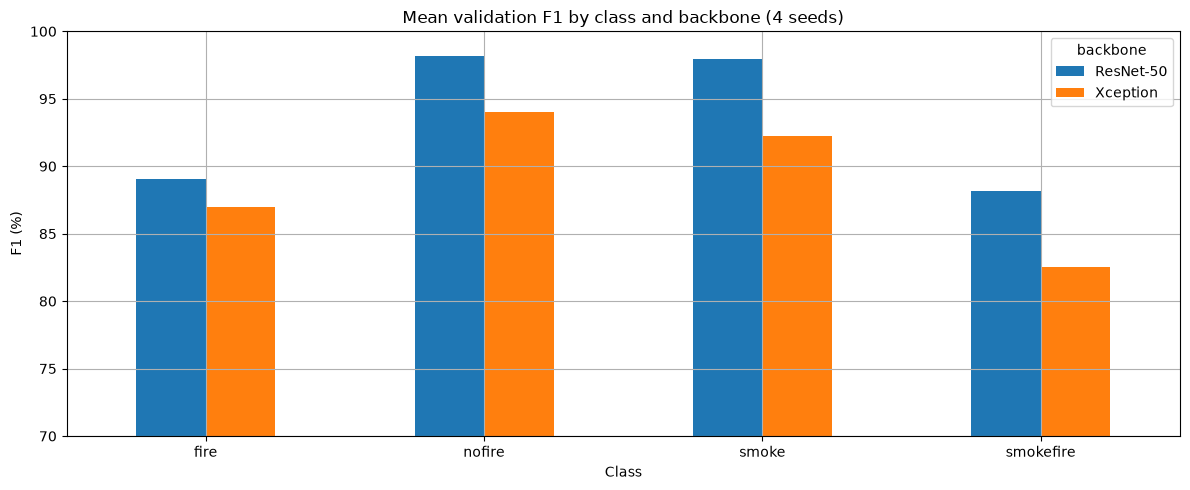

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
comparison.pivot(index='seed', columns='backbone', values='accuracy').mul(100).plot(kind='bar', ax=axes[0], ylim=(85, 100), grid=True)
axes[0].set(title='Validation accuracy by seed', ylabel='Accuracy (%)', xlabel='Seed')
comparison.pivot(index='seed', columns='backbone', values='macro_f1').mul(100).plot(kind='bar', ax=axes[1], ylim=(85, 100), grid=True)
axes[1].set(title='Validation macro F1 by seed', ylabel='Macro F1 (%)', xlabel='Seed')
for axis in axes:
    axis.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

class_f1 = comparison.groupby('backbone')[[f'f1_{name}' for name in CLASS_NAMES]].mean().T.reindex([f'f1_{name}' for name in CLASS_NAMES]).mul(100)
class_f1.index = CLASS_NAMES
class_f1.plot(kind='bar', figsize=(12, 5), ylim=(70, 100), grid=True, title='Mean validation F1 by class and backbone (4 seeds)')
plt.ylabel('F1 (%)')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Conclusion and scope

Under this locked validation protocol, ResNet-50 achieved mean accuracy of 93.34% and mean macro F1 of 93.34%, compared with 88.94% and 88.96% for Xception. This is an improvement of about 4.41 percentage points in accuracy and 4.38 points in macro F1. ResNet-50 also had lower population variance for both metrics.

These results are validation-only. They are not an independent test-set comparison; checkpoint selection also used validation macro F1. The saved per-seed and mean/variance tables are `results/frozen_backbone_comparison_per_seed.csv` and `results/frozen_backbone_comparison_mean_variance.csv`.
